## White Blood Cell Classification project



##### STEP 1: Mount Google Drive

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### STEP 2: Import Libraries

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

##### STEP 3: Set Device

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


##### STEP 4: Set Correct Dataset Paths

In [23]:
"/content/drive/MyDrive/white_blood_cells"

'/content/drive/MyDrive/white_blood_cells'

In [24]:
base_path = "/content/drive/MyDrive/white_blood_cells"

train_path = os.path.join(base_path, "Train")
test_path_A = os.path.join(base_path, "Test-A")
test_path_B = os.path.join(base_path, "Test-B")

##### STEP 5: Image Preprocessing

In [26]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.ImageFolder(
    root=train_path,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_path_A, # test on Test-B # root=test_path_B
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


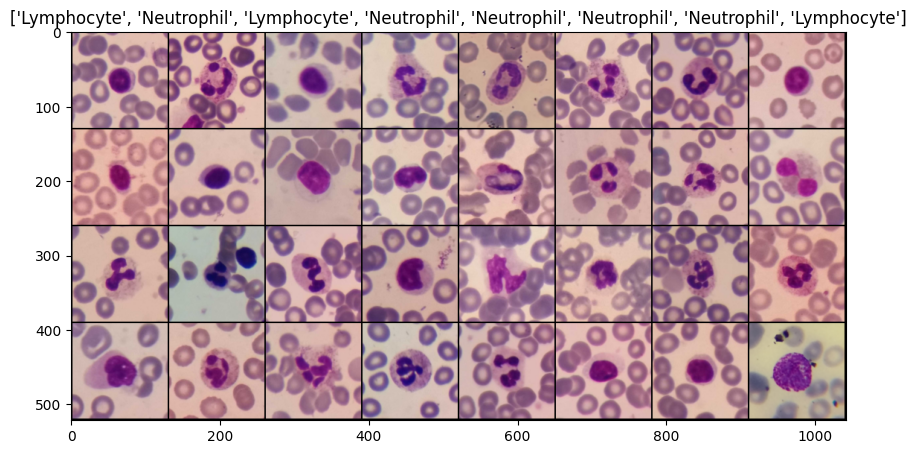

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title=None):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 8))
imshow(torchvision.utils.make_grid(images[:32]),
       title=[class_names[labels[j]] for j in range(8)])

##### STEP 6: Load Training Dataset

In [28]:
train_dataset = torchvision.datasets.ImageFolder(
    root=train_path,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


##### STEP 7: Load Test Dataset

In [29]:
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path_A, # test on Test-B # root=test_path_B
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##### STEP 8: Model A

In [30]:
class ModelA(nn.Module):
    def __init__(self, num_classes):
        super(ModelA, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

##### STEP 9: Model B

In [31]:
class ModelB(nn.Module):
    def __init__(self, num_classes):
        super(ModelB, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

##### STEP 10: Stacking Ensemble

In [32]:
class StackingModel(nn.Module):
    def __init__(self, modelA, modelB, num_classes):
        super(StackingModel, self).__init__()

        self.modelA = modelA
        self.modelB = modelB

        self.meta_layer = nn.Linear(num_classes * 2, num_classes)

    def forward(self, x):
        outA = self.modelA(x)
        outB = self.modelB(x)

        combined = torch.cat((outA, outB), dim=1)
        output = self.meta_layer(combined)

        return output

##### STEP 11: Initialize Models

In [33]:
modelA = ModelA(num_classes).to(device)
modelB = ModelB(num_classes).to(device)

stacking_model = StackingModel(modelA, modelB, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(stacking_model.parameters(), lr=0.001)

##### STEP 12: Train

In [17]:
num_epochs = 20

for epoch in range(num_epochs):
    stacking_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = stacking_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {total_loss:.4f}")

Epoch [1/20] Loss: 88.0515
Epoch [2/20] Loss: 60.7757
Epoch [3/20] Loss: 42.2575
Epoch [4/20] Loss: 30.4632
Epoch [5/20] Loss: 23.1975
Epoch [6/20] Loss: 17.4067
Epoch [7/20] Loss: 13.8754
Epoch [8/20] Loss: 12.5682
Epoch [9/20] Loss: 6.7570
Epoch [10/20] Loss: 8.2945
Epoch [11/20] Loss: 10.4453
Epoch [12/20] Loss: 7.1425
Epoch [13/20] Loss: 4.2343
Epoch [14/20] Loss: 0.9481
Epoch [15/20] Loss: 0.4019
Epoch [16/20] Loss: 7.9295
Epoch [17/20] Loss: 4.1471
Epoch [18/20] Loss: 0.9757
Epoch [19/20] Loss: 0.2132
Epoch [20/20] Loss: 0.0933


##### STEP 13: Accuracy Result

In [18]:
stacking_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = stacking_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 92.72%
